In [1]:

import os
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent)) 
from acados_template import AcadosOcp
from commom_utils.ode_system import ODESystem, check_system_ok, MHESyntheticDataGenerator
import numpy as np
import matplotlib.pyplot as plt

from commom_utils.systems import *
from commom_utils.system_config import create_system, create_mhe_params, SYSTEM_CONFIGS
from mhe.mhe_base_model_interface import MheModel, MheCogeGenerator
from mhe.params import MheParams
from mhe.mhe_utils import MheEstimationData, run_mhe_estimation, plot_mhe_results, reset_mhe_solver, plot_mhe_data_windows

In [2]:
for ss in SYSTEM_CONFIGS.keys():
    print(ss)

LotkaVoltera
LateralCarDynamic
Attractor
Pendulum
Delay
MassSpringDamper
KinematicBycicle
KinematicModelDelay
Integrator
DelaySystem
OffsetEstimator


In [3]:
model_name = "LotkaVoltera"
system, c0, theta_true, delta_theta = create_system(model_name)
mhe_params = create_mhe_params(model_name, dt=0.02, mhe_horizont=300)
mhe_params.print()
# ... инициализация и запуск MHE

dt: 0.02
mhe_horizont: 300
state_prior_q0: [[1. 0.]
 [0. 1.]]
noise_peanlty_w: [[1000.    0.]
 [   0. 1000.]]
measurements_residual_r: [[1. 0.]
 [0. 1.]]
bounds_param: [[-2000, 2000], [-2000, 2000], [-2000, 2000], [-2000, 2000]]
bounds_state: [[-inf, inf], [-inf, inf]]
bounds_noise: [[-0.01, 0.01], [-0.01, 0.01]]
fim_scaler: 0.2


In [ ]:
class MyCogeGenerator(MheCogeGenerator):
    def __init__(self):
        super().__init__(system, mhe_params,  Path(os.getcwd())/'tmp_generated', 'kinematik_mhe')

    def modify_ocp_problem(self, ocp_mhe: AcadosOcp) -> AcadosOcp:
        ocp_mhe.solver_options.print_level = 1
        ocp_mhe.solver_options.nlp_solver_stats_level = 2

        # ocp_mhe.solver_options.integrator_type = 'IRK'
        # ocp_mhe.solver_options.sim_method_num_stages = 3
        # ocp_mhe.solver_options.sim_method_newton_tol = 1e-9
        # ocp_mhe.solver_options.sim_method_newton_iter = 10

        # # В настройках решателя
        # ocp_mhe.solver_options.nlp_solver_type = 'SQP'
        ocp_mhe.solver_options.nlp_solver_max_iter = 30
        # ocp_mhe.solver_options.levenberg_marquardt = 1e-6
        # ocp_mhe.solver_options.globalization = 'FIXED_STEP'
        # ocp_mhe.solver_options.globalization_fixed_step_length = 0.9
        # ocp_mhe.solver_options.nlp_solver_tol_stat = 1e-4   # временно ослабить
        # ocp_mhe.solver_options.nlp_solver_tol_eq = 1e-4
        # ocp_mhe.solver_options.nlp_solver_tol_ineq = 1e-4
        # ocp_mhe.solver_options.nlp_solver_tol_comp = 1e-4

        # ocp_mhe.solver_options.nlp_solver_max_iter =120
        # #ocp_mhe.solver_options.nlp_solver_tol_stat = 1e-3
        # ocp_mhe.solver_options.nlp_solver_type = 'SQP'
        # ocp_mhe.solver_options.nlp_solver_max_iter = 200
        # ocp_mhe.solver_options.nlp_solver_tol_stat = 1e-4
        # ocp_mhe.solver_options.nlp_solver_tol_eq = 1e-4
        # ocp_mhe.solver_options.nlp_solver_tol_ineq = 1e-4
        # ocp_mhe.solver_options.nlp_solver_tol_comp = 1e-4
        # ocp_mhe.solver_options.hessian_approx = 'GAUSS_NEWTON'
        # ocp_mhe.solver_options.globalization = 'FIXED_STEP'
        # ocp_mhe.solver_options.globalization_fixed_step_length = 0.9
        # ocp_mhe.solver_options.levenberg_marquardt = 1e-6
        # ocp_mhe.solver_options.qp_solver = 'PARTIAL_CONDENSING_HPIPM'
        # ocp_mhe.solver_options.hpipm_options = {
        #     'scale': 1,
        #     'scale_ux': 1,
        #     'iter_max': 1000,
        #     'tol': 1e-6,
        #     'reg_epsilon': 1e-6,
        #     'reg_epsilon_s': 1e-6,
        # }
        return ocp_mhe

generator = MyCogeGenerator()

#assert check_system_ok(system) == True

acados_solver_mhe = generator.generate_code()

Please export ACADOS_SOURCE_DIR to avoid this warning.
[-2000. -2000. -2000. -2000.]
[2000. 2000. 2000. 2000.]
[2 3 4 5]
kinematik_mhe
4 2

got cost_type EXTERNAL for cost_type_0, cost_type, cost_type_e, hessian_approx: 'GAUSS_NEWTON'.
With this setting, acados will proceed computing the exact Hessian for the cost term and no Hessian contribution from constraints and dynamics.
If the external cost is a linear least squares cost, this coincides with the Gauss-Newton Hessian.
Note: There is also the option to use the external cost module with a numerical Hessian approximation (see `ext_cost_num_hess`).
OR the option to provide a symbolic custom Hessian approximation (see `cost_expr_ext_cost_custom_hess`).


got cost_type EXTERNAL for cost_type_0, cost_type, cost_type_e, hessian_approx: 'GAUSS_NEWTON'.
With this setting, acados will proceed computing the exact Hessian for the cost term and no Hessian contribution from constraints and dynamics.
If the external cost is a linear least square

In [5]:
# Create the generator

simulation_system = system# KinematicBycicleActuator(wheelbase=2.65, kp = 200, kv = 10)

data_gen = MHESyntheticDataGenerator(simulation_system, sigma=0.0)

# Parameters
t0 = 0
T_f = mhe_params.dt * mhe_params.mhe_horizont          
N_measurement = mhe_params.mhe_horizont           
overlap_points = int(N_measurement*0.5)
num_windows = 20                                    # number of overlapping windows


# Generate exact windows
t_windows, u_windows, meas_windows, full_windows = data_gen.generate_sliding_windows_exact(
    c0, theta_true, t0, T_f, num_windows, N_measurement + 1, overlap_points=overlap_points, sigma = 0.1
)

# Check the time span of the first window
print(f"Window 0: start={t_windows[0][0]:.6f}, end={t_windows[0][-1]:.6f}, span={t_windows[0][-1]-t_windows[0][0]:.6f}")
# This should equal T_f
def get_window(i):
    return t_windows[i], u_windows[i][:], meas_windows[i], full_windows[i]

INFO:2026-05-11 16:01:23,787:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-05-11 16:01:23,787 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


Window 0: start=0.000000, end=6.000000, span=6.000000


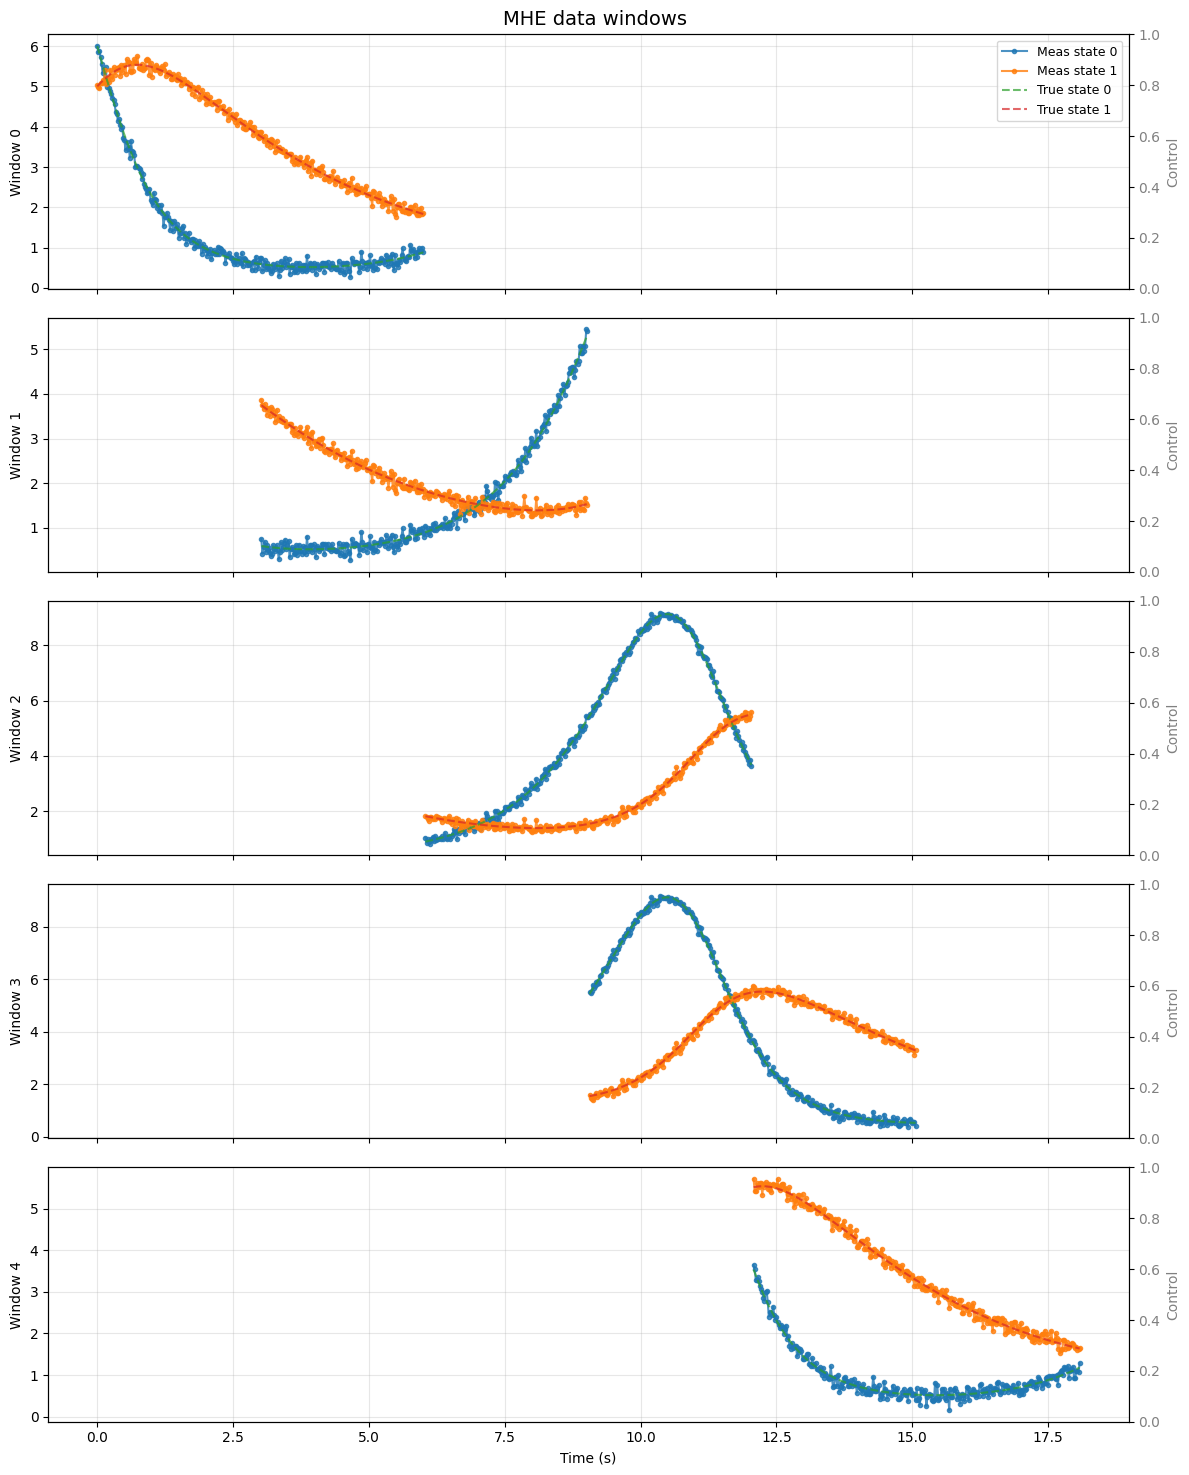

In [6]:
plot_mhe_data_windows(t_windows, u_windows, meas_windows, full_windows,
                      max_windows=5, state_idx=[0, 1])

In [7]:
def make_system_trajectory(mhe_model: MheModel, 
               simU: np.array, 
               initial_x0: np.array, 
               initial_theta: np.array, 
               N: int) -> tuple :
    assert(len(initial_x0) == mhe_model.state_length)
    assert(len(initial_theta) == mhe_model.param_length)
    assert simU.shape[0] >= N, f"simU должен содержать хотя бы {N} строк"

    x_sim = initial_x0.copy()
    trajectory = np.zeros((N + 1, mhe_model.state_length))
    integrate_f = mhe_model.create_integrate_function(0.02, "integrate")
    trajectory[0] = x_sim
    for j in range(N):
        # Формируем расширенный вектор состояния + параметров
        x_aug = np.hstack((x_sim, initial_theta))
        acados_solver_mhe.set(j, "x", x_aug)

        # Делаем шаг вперёд по дискретной динамике
        if j < N - 1:
            x_sim = np.array(integrate_f(x_sim, initial_theta, simU[j, :])).T[0]
        trajectory[j + 1] = x_sim
    return trajectory


In [14]:
initial_theta = theta_true*0.2
acados_solver_mhe.reset()
t, imput_signal, measurements, _ = get_window(0)
x0_est = system.get_initial_state(measurements[0], imput_signal[0], initial_theta)
reset_mhe_solver(generator.get_model(), 
                 acados_solver_mhe,
                 imput_signal,
                 x0_est,
                 initial_theta,
                 N_measurement
                 )
print("initial_theta: ", initial_theta)
print("theta_true: ", theta_true)

create_step_function integrate
4
initial_theta:  [0.24 0.08 0.06 0.02]
theta_true:  [1.2 0.4 0.3 0.1]


In [15]:


results = run_mhe_estimation(
    mhe_model=generator.get_model(),
    acados_solver_factory= acados_solver_mhe,   # you might pass a pre‑created solver or a factory
    get_window_func=get_window,
    get_initial_state_func=system.get_initial_state,
    overlap_points=overlap_points,
    initial_theta = initial_theta,
    mhe_params=mhe_params,
    num_windows=8,
    ridge_reg = 1e-0,
    R_inv=mhe_params.measurements_residual_r,
    forgetting_factor = 0.01,
    compute_advanced_fim = True,
    plot=0   # set to True if you want live plots
)

MHE windows:   0%|          | 0/8 [00:00<?, ?window/s]

2026-05-11 16:04:44,449 - WARNING - Window 0: acados returned status 2. Skipping this window.
MHE windows:  12%|█▎        | 1/8 [00:00<00:02,  2.55window/s]

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   2.2926e-01   5.9794e+00   0.0000e+00   0.0000e+00         0         0   0.00e+00   0.00e+00  1.00e+00    
     1   4.4667e-01   2.6385e-02   0.0000e+00   6.7531e-10         0         5   5.55e+00   1.00e-06  1.00e+00    
     2   1.9499e-01   1.1582e-02   0.0000e+00   6.5929e-08         0         5   1.17e+00   1.00e-06  1.00e+00    
     3   2.0513e-02   1.8110e-03   0.0000e+00   2.6298e-08         0         5   4.41e-01   1.00e-06  1.00e+00    
     4   1.7007e-02   9.0313e-05   0.0000e+00   4.5712e-08         0         5   2.34e-01   1.00e-06  1.00e+00    
     5   1.0689e-02   7.9255e-05   0.0000e+00   4.6678e-08         0         5   1.03e-01   1.00e-06  1.00e+00    
     6   4.1512e-03   7.5815e-06   0.0000e+00   5.2005e-08         0         5   6.63e-02   1.00e-06  1.00e+00    
     7   3.3764e-03   6.2721e-06   0.0000e+00   5.2093e-08         0         5   

MHE windows:  25%|██▌       | 2/8 [00:00<00:02,  2.77window/s]

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   6.5553e-01   4.6907e-10   0.0000e+00   5.4147e-08         0         0   0.00e+00   0.00e+00  1.00e+00    
     1   1.2901e-01   4.7731e-02   0.0000e+00   4.2169e-08         0         5   2.62e+00   1.00e-06  1.00e+00    
     2   2.4375e-02   9.0389e-02   0.0000e+00   6.5052e-07         0         4   4.69e+00   1.00e-06  1.00e+00    
     3   6.1316e-03   3.9314e-03   0.0000e+00   1.8510e-07         0         4   1.22e+00   1.00e-06  1.00e+00    
     4   6.9084e-04   1.2753e-05   0.0000e+00   1.3159e-07         0         4   7.81e-02   1.00e-06  1.00e+00    
     5   7.3129e-06   1.8837e-09   0.0000e+00   1.3153e-07         0         4   1.37e-03   1.00e-06  1.00e+00    
     6   1.1467e-07   2.9594e-12   0.0000e+00   1.3153e-07         0         4   3.06e-05   1.00e-06  1.00e+00    
Optimal solution found! Converged to KKT point.


...

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   1.5734e+01   2.5180e-13   0.0000e+00   5.3685e-07         0         0   0.00e+00   0.00e+00  1.00e+00    
     1   2.0085e-01   9.5282e-02   0.0000e+00   8.6995e-07         0         4   4.11e+00   1.00e-06  1.00e+00    
     2   1.2344e-02   2.2491e-03   0.0000e+00   7.8324e-08         0         4   1.93e+00   1.00e-06  1.00e+00    
     3   4.6853e-04   4.3317e-05   0.0000e+00   1.4227e-07         0         4   8.07e-02   1.00e-06  1.00e+00    
     4   1.7833e-05   5.5017e-08   0.0000e+00   1.4496e-07         0         4   2.49e-03   1.00e-06  1.00e+00    
     5   1.2399e-06   1.9948e-10   0.0000e+00   1.4492e-07         0         4   7.14e-05   1.00e-06  1.00e+00    
     6   1.7962e-08   2.3803e-13   0.0000e+00   1.4492e-07         0         4   3.40e-06   1.00e-06  1.00e+00    
Optimal solution found! Converged to KKT point.


2026-05-11 16:04:46,635 - WARNING - Window 6: acados returned status 2. Skipping this window.
MHE windows:  88%|████████▊ | 7/8 [00:02<00:00,  2.72window/s]

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   3.9057e+00   2.3803e-13   0.0000e+00   1.4492e-07         0         0   0.00e+00   0.00e+00  1.00e+00    
     1   6.3850e+00   1.0589e-01   0.0000e+00   5.7786e-07         0         5   4.43e+00   1.00e-06  1.00e+00    
     2   5.0102e-01   2.6398e-02   0.0000e+00   5.2615e-09         0         6   2.42e+00   1.00e-06  1.00e+00    
     3   4.6418e-01   6.1261e-03   0.0000e+00   5.3491e-07         0         5   7.45e-01   1.00e-06  1.00e+00    
     4   5.8103e-01   3.3788e-03   0.0000e+00   7.0290e-07         0         5   1.37e+00   1.00e-06  1.00e+00    
     5   6.0948e-01   6.1564e-03   0.0000e+00   4.9460e-07         0         5   5.27e-01   1.00e-06  1.00e+00    
     6   4.8320e-01   3.4602e-03   0.0000e+00   1.1875e-07         0         5   6.28e-01   1.00e-06  1.00e+00    
     7   6.0461e-01   5.5521e-03   0.0000e+00   4.0188e-07         0         5   

MHE windows: 100%|██████████| 8/8 [00:02<00:00,  2.72window/s]

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   5.6115e+00   5.8484e-03   0.0000e+00   2.8346e-07         0         0   0.00e+00   0.00e+00  1.00e+00    
     1   4.7702e+00   1.0870e-01   0.0000e+00   2.5486e-09         0         5   9.90e+00   1.00e-06  1.00e+00    
     2   5.5057e-01   4.1954e-02   0.0000e+00   1.0435e-07         0         5   3.58e+00   1.00e-06  1.00e+00    
     3   2.6389e-01   2.0202e-03   0.0000e+00   1.0314e-07         0         5   8.81e-01   1.00e-06  1.00e+00    
     4   1.7214e-02   7.2968e-06   0.0000e+00   1.0489e-07         0         5   7.18e-02   1.00e-06  1.00e+00    
     5   1.3147e-03   1.7291e-07   0.0000e+00   1.0433e-07         0         5   8.51e-03   1.00e-06  1.00e+00    
     6   4.8628e-04   2.4623e-08   0.0000e+00   1.0436e-07         0         5   2.04e-03   1.00e-06  1.00e+00    
     7   5.7360e-05   1.8782e-09   0.0000e+00   1.0435e-07         0         5   

(754, 2)
(754, 2)


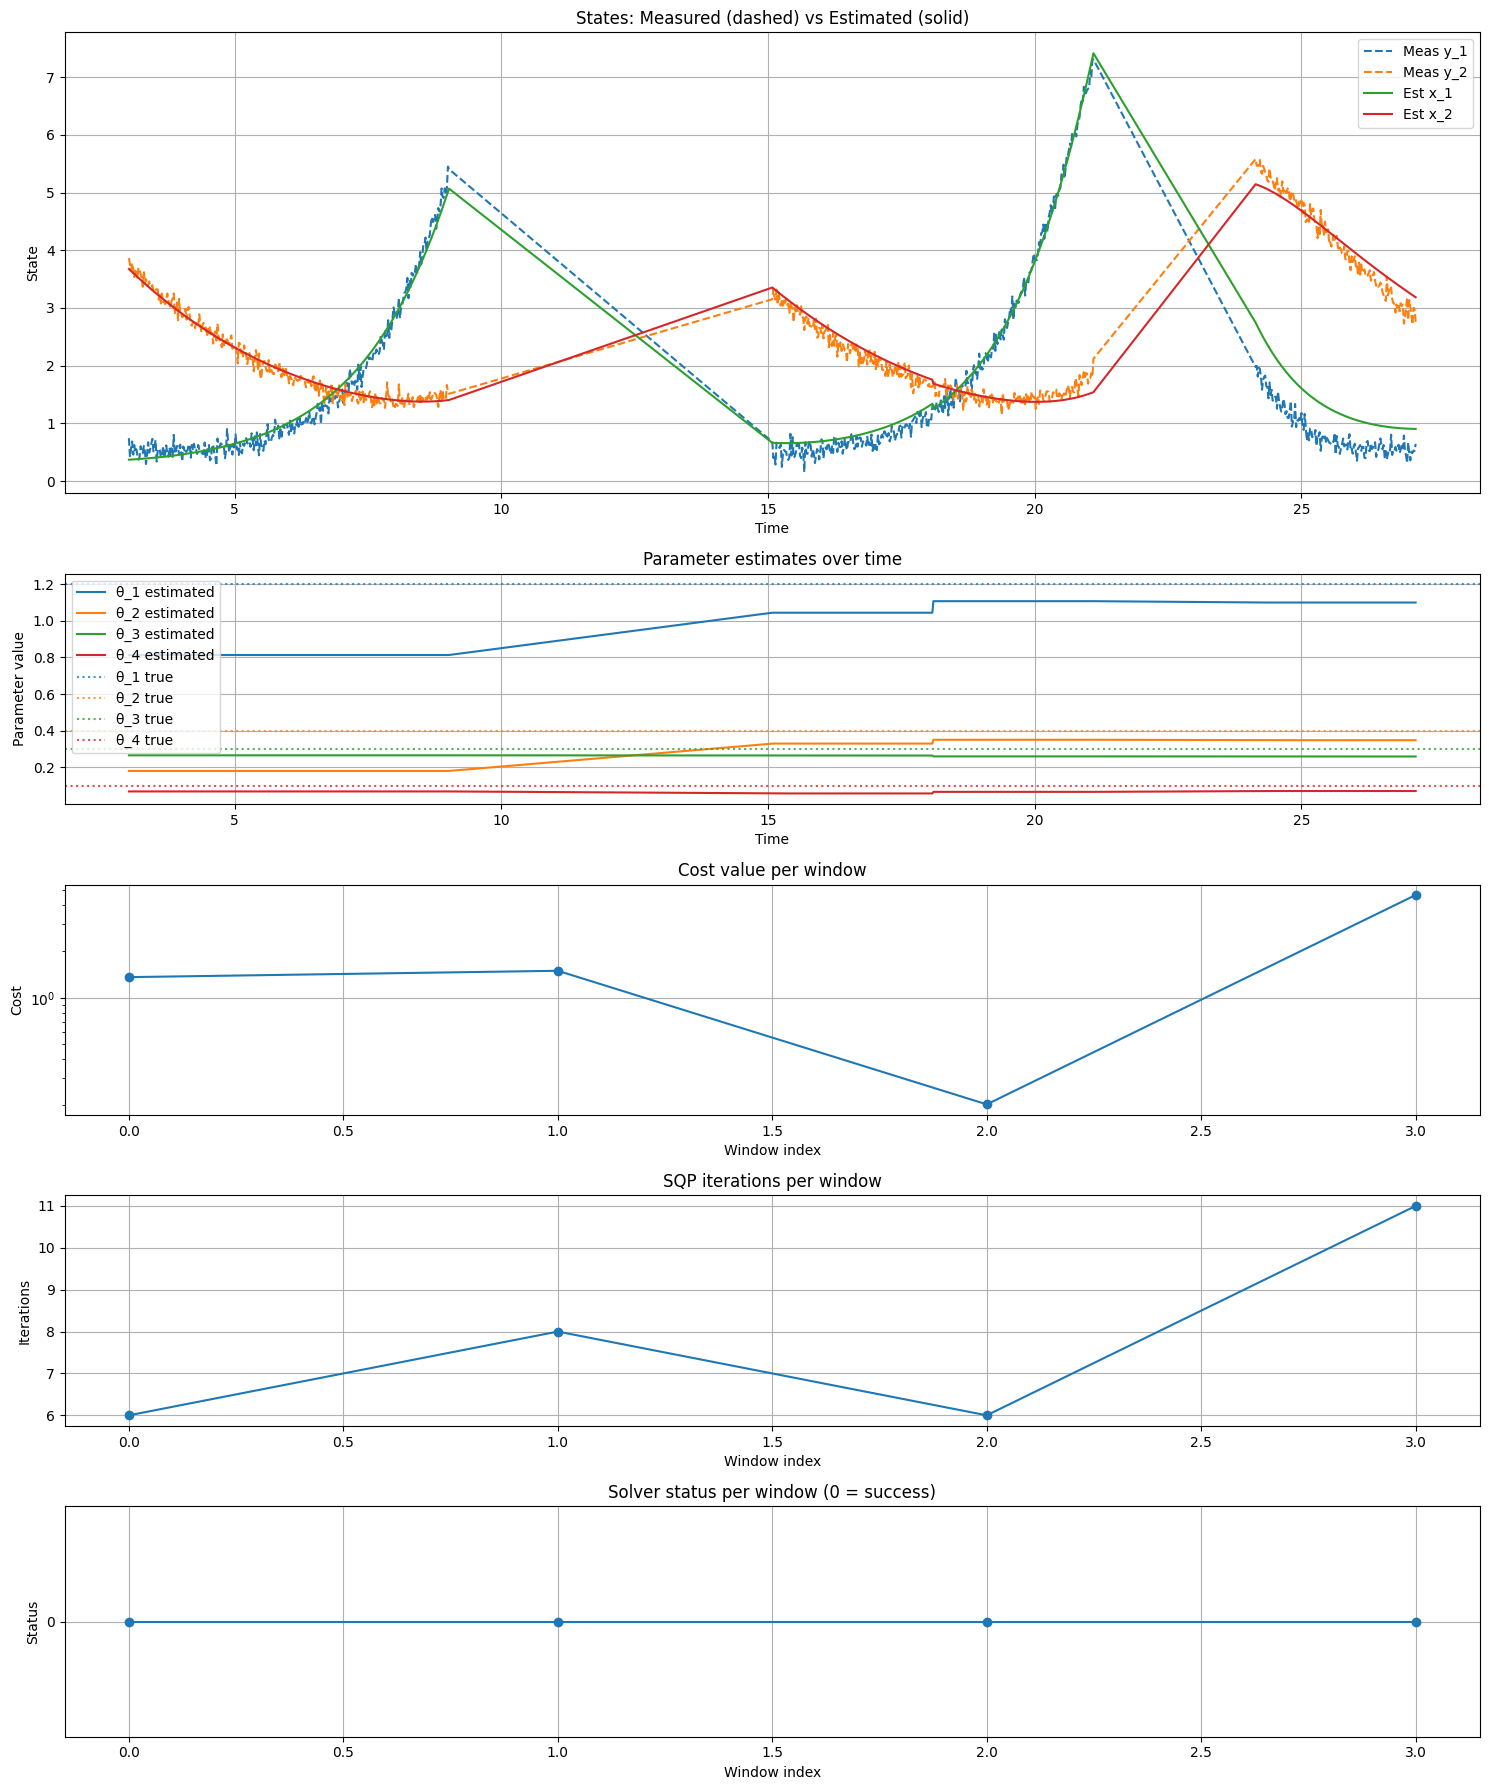

In [16]:
plot_mhe_results(results, overlap=overlap_points,
                 initial_params=None,
                 theta_true=theta_true,   # your true parameter array
                 plot_states=True,
                 plot_params=True,
                 plot_eigvals=False,
                 plot_noise=False,
                 plot_cost=True,
                 plot_iter=True,
                 plot_status=True,
                 plot_cov_matrix = False,
                 figsize=(15, 18))   # slightly larger to accommodate taller first plot

In [10]:
initial_theta = theta_true
t_batch, simU, simY = get_window(10)
unknown_state_length = 0


initial_x0 = np.hstack((simY[0]))
print(initial_x0)
R_inv = np.diag(1*[1])
mhe_model=generator.get_model()
F = mhe_model.compute_fim(simY.shape[0], mhe_params.dt, simU, initial_x0, initial_theta, R_inv)
F
#set_mhe_solver(mhe_model, acados_solver_mhe, simY, simU, initial_x0, initial_theta, mhe_params.dt, N_measurement, unknown_state_length, R_inv)

[-1.23968548]


array([[ 1361.03263992,  8277.43431679],
       [ 8277.43431679, 52041.04294695]])

In [11]:
simU.shape

(501, 1)